# Visualizing distributions of data ⭐

📄 Source: https://seaborn.pydata.org/tutorial/distributions.html

Understanding how variables are distributed is an early step in any analysis: What range? What central tendency? Skewed? Bimodal? Outliers? Do these differ across subsets?

- Axes-level functions: `histplot`, `kdeplot`, `ecdfplot`, `rugplot`
- Figure-level functions that group them: `displot`, `jointplot`, `pairplot`

Each approach has strengths and weaknesses; this page is about choosing well.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()
print("seaborn", sns.__version__)

seaborn 0.13.2


## Plotting univariate histograms

A histogram splits the data axis into **bins** and shows the **count** in each bin as a bar height. It's the default of `displot` (same code as `histplot`):

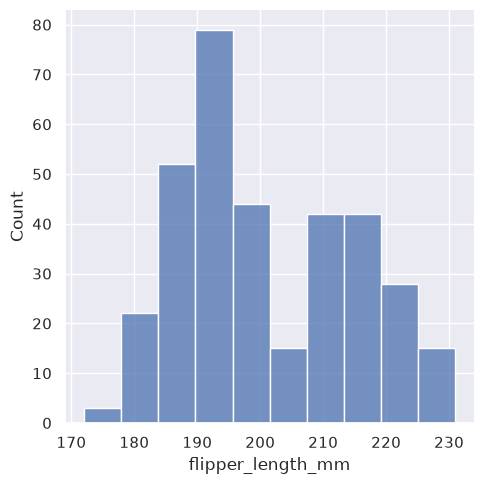

In [2]:
penguins = sns.load_dataset("penguins")
sns.displot(penguins, x="flipper_length_mm")

Most common flipper length ≈ 195 mm, but the distribution looks **bimodal**, so one number doesn't describe it well.

### Choosing the bin size

The wrong bin size can **hide** real features or **create** fake ones from noise. The default depends on the variance and the number of observations, but always check your impression with other bin sizes. Set the width directly:

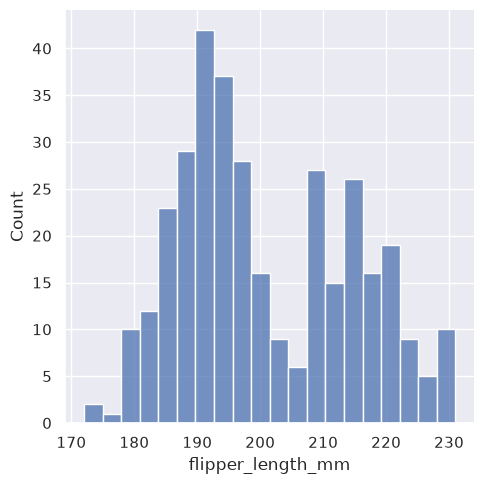

In [3]:
sns.displot(penguins, x="flipper_length_mm", binwidth=3)

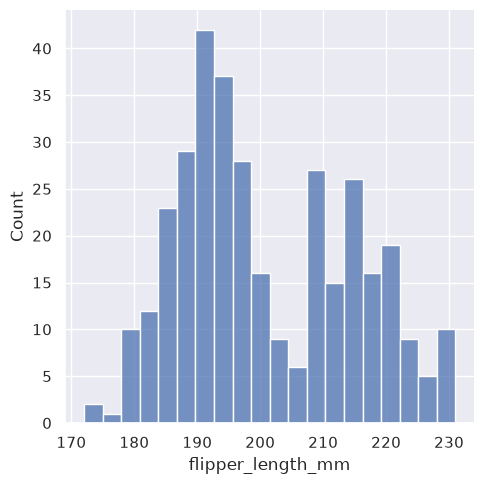

In [4]:
# Or set the NUMBER of bins
sns.displot(penguins, x="flipper_length_mm", bins=20)

Defaults fail when a variable takes **few integer values**: awkward gaps appear.

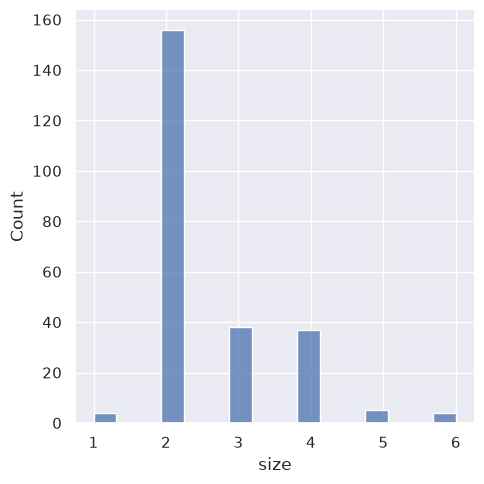

In [5]:
tips = sns.load_dataset("tips")
sns.displot(tips, x="size")   # party size: integers 1-6

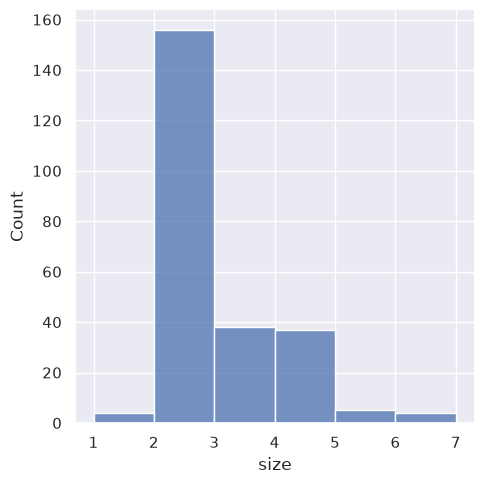

In [6]:
# Fix 1: give the exact bin edges
sns.displot(tips, x="size", bins=[1, 2, 3, 4, 5, 6, 7])

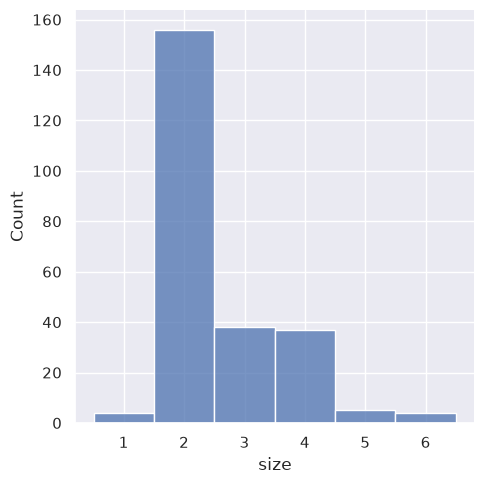

In [7]:
# Fix 2: discrete=True -> one bin per unique value, bar centred on it
sns.displot(tips, x="size", discrete=True)

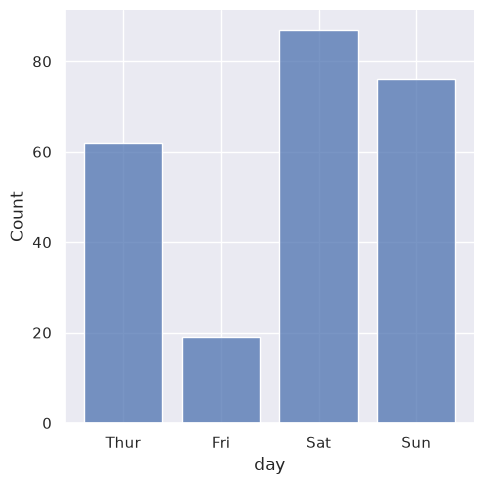

In [8]:
# Categorical variable: bins are automatic; shrink the bars to show it's categorical
sns.displot(tips, x="day", shrink=.8)

### Conditioning on other variables

Does the distribution differ across other variables? What explains the bimodality? Use `hue` for one histogram per level:

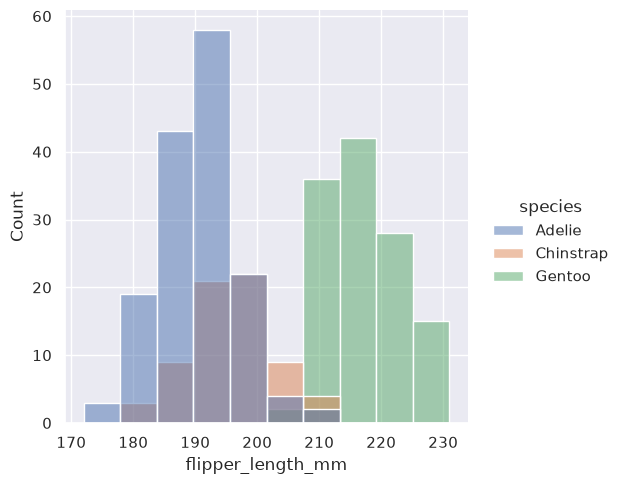

In [9]:
sns.displot(penguins, x="flipper_length_mm", hue="species")

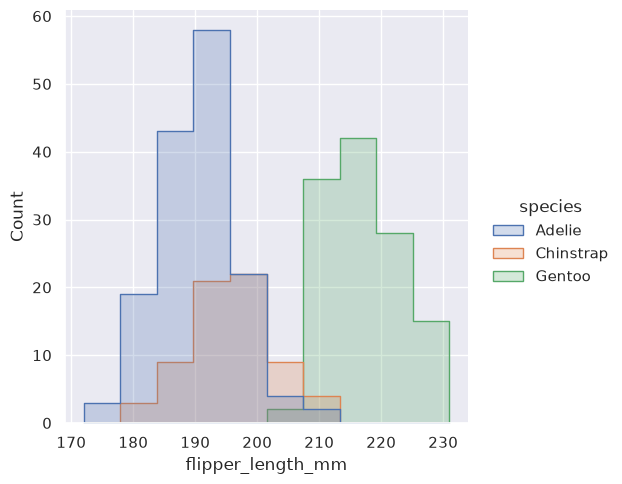

In [10]:
# Layered bars can be hard to read: use a "step" outline instead
sns.displot(penguins, x="flipper_length_mm", hue="species", element="step")

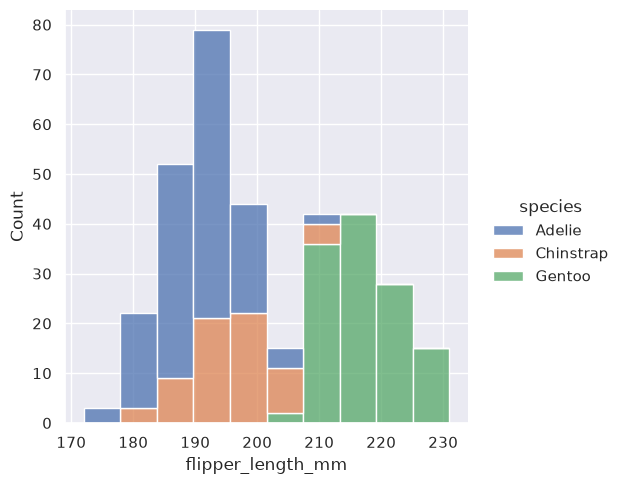

In [11]:
# Stack them: the outline equals the single-variable histogram (part-whole view)
sns.displot(penguins, x="flipper_length_mm", hue="species", multiple="stack")

Stacking hides other features (e.g. where is the Adelie mode?). **Dodge** puts bars side by side, comparable in height, but only works with few levels:

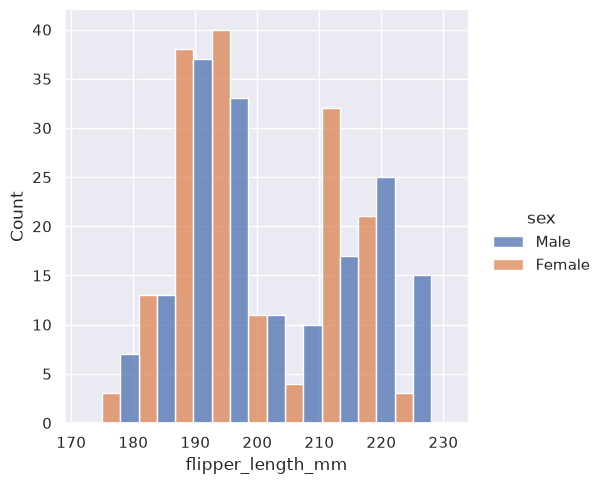

In [12]:
sns.displot(penguins, x="flipper_length_mm", hue="sex", multiple="dodge")

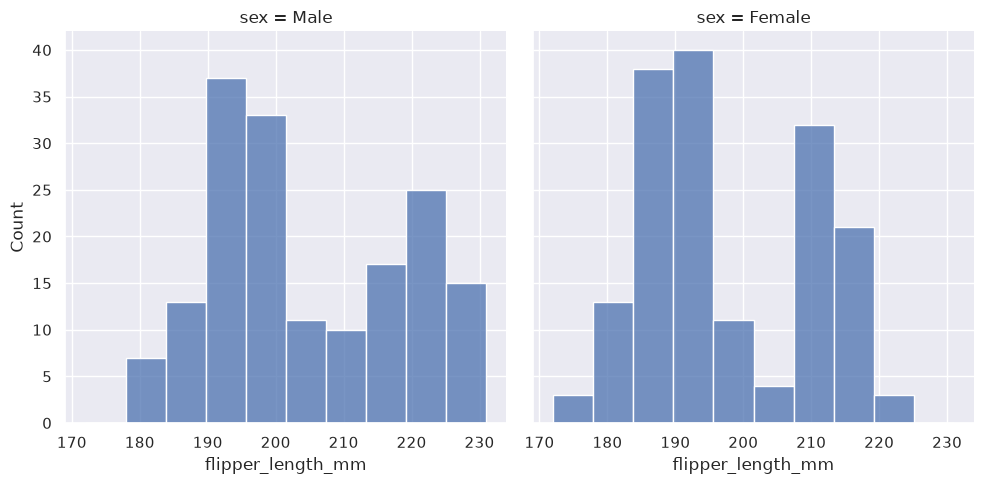

In [13]:
# displot is figure-level -> one subplot per level with col= (good per subset, harder to compare)
sns.displot(penguins, x="flipper_length_mm", col="sex")

None of these is perfect; KDE and ECDF below are better for comparison.

### Normalized histogram statistics

When subsets have **different sizes**, comparing raw counts is misleading. Normalise with `stat`:

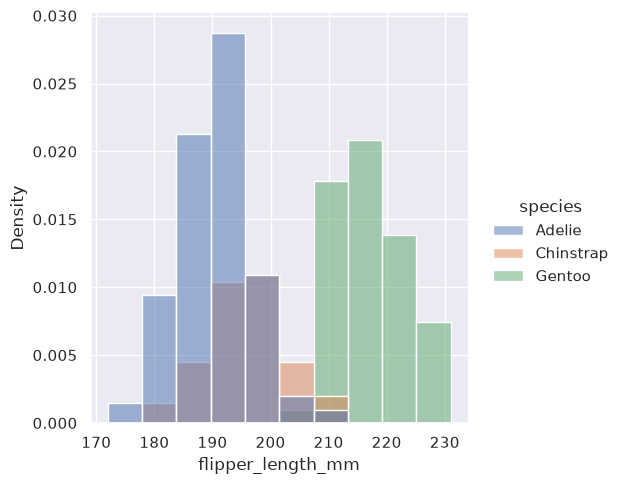

In [14]:
sns.displot(penguins, x="flipper_length_mm", hue="species", stat="density")

By default the normalisation is over the **whole** dataset (it just rescales the bars). `common_norm=False` normalises **each subset** on its own:

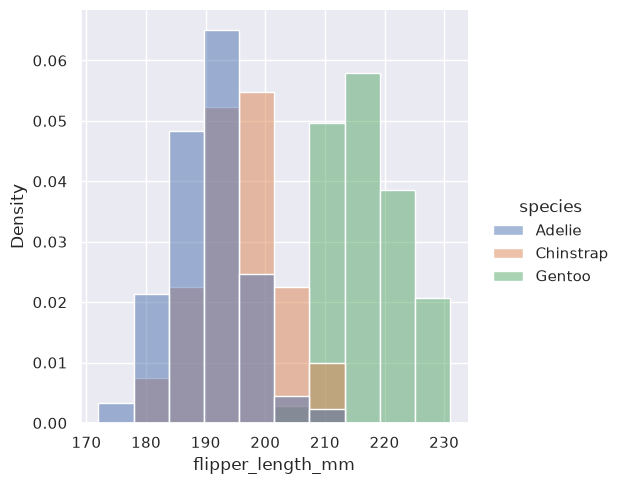

In [15]:
sns.displot(penguins, x="flipper_length_mm", hue="species", stat="density", common_norm=False)

`stat="density"` → bar **areas** sum to 1 (the y-axis isn't directly readable). `stat="probability"` → bar **heights** sum to 1 (most sensible for discrete data):

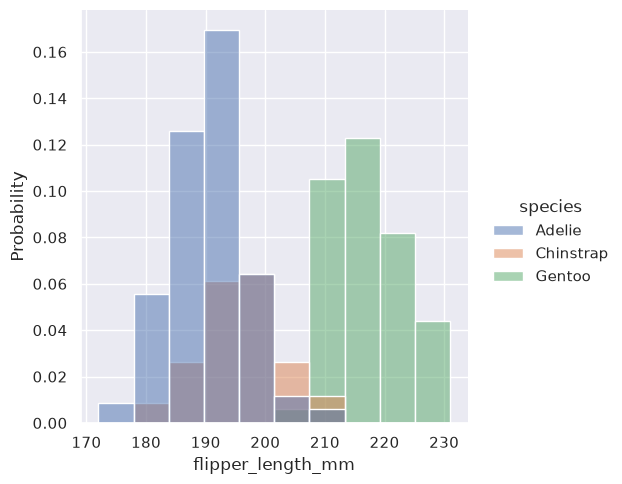

In [16]:
sns.displot(penguins, x="flipper_length_mm", hue="species", stat="probability")

## Kernel density estimation

A histogram approximates the underlying probability density by binning and counting. **KDE** instead smooths each observation with a **Gaussian kernel** to give a continuous curve:

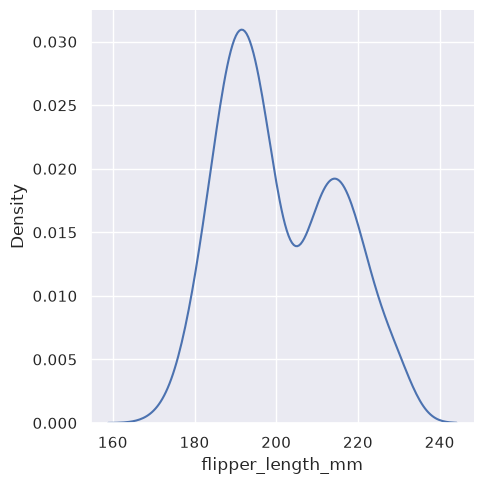

In [17]:
sns.displot(penguins, x="flipper_length_mm", kind="kde")

### Choosing the smoothing bandwidth

Like bin size: over-smoothing erases real features, under-smoothing shows noise. Check robustness with `bw_adjust` (a multiplier on the default bandwidth):

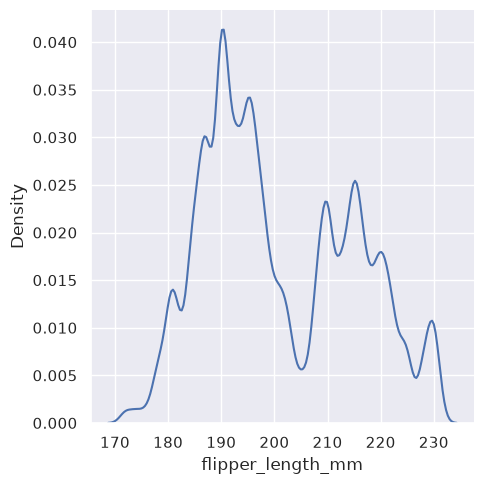

In [18]:
sns.displot(penguins, x="flipper_length_mm", kind="kde", bw_adjust=.25)   # narrow: bimodality clear, curve bumpy

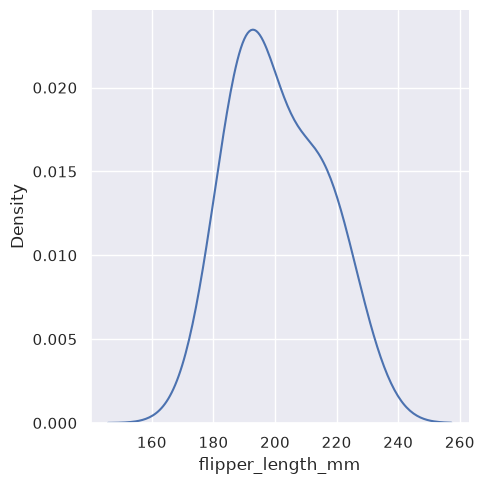

In [19]:
sns.displot(penguins, x="flipper_length_mm", kind="kde", bw_adjust=2)     # wide: bimodality almost gone

### Conditioning on other variables

With `hue`, one density per level. Layered KDEs are often **easier to compare** than layered histograms:

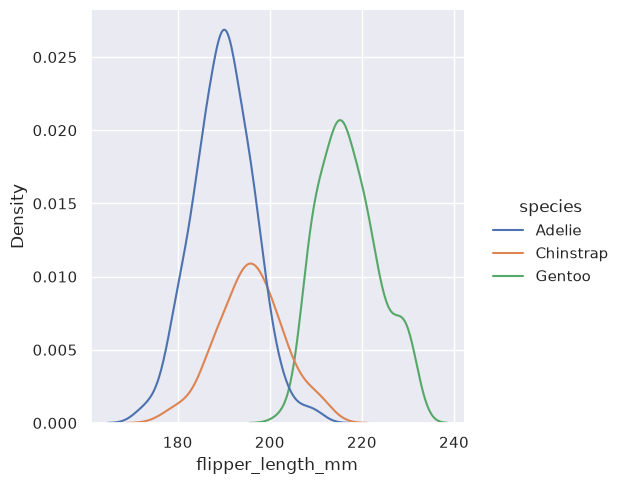

In [20]:
sns.displot(penguins, x="flipper_length_mm", hue="species", kind="kde")

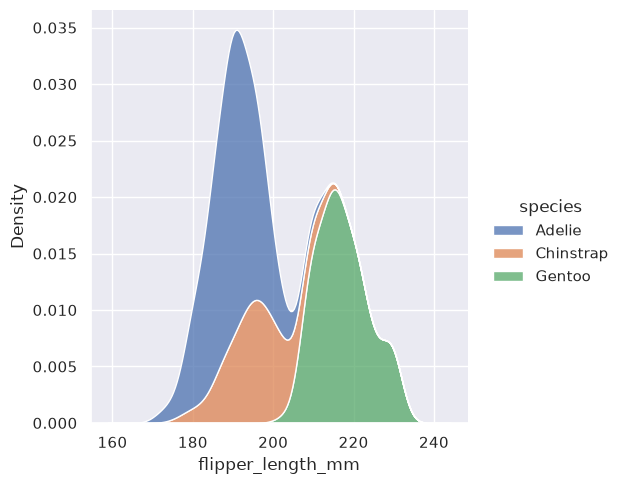

In [21]:
sns.displot(penguins, x="flipper_length_mm", hue="species", kind="kde", multiple="stack")   # stacked -> filled by default

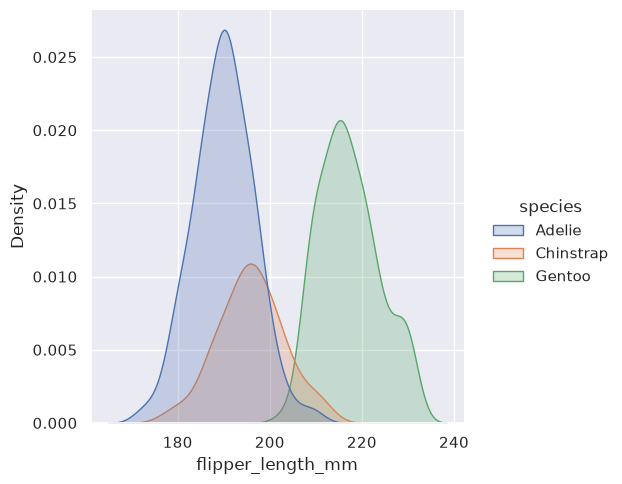

In [22]:
sns.displot(penguins, x="flipper_length_mm", hue="species", kind="kde", fill=True)   # filled, with lower alpha so they stay readable

### ⚠️ Kernel density estimation pitfalls

KDE assumes the true distribution is **smooth and unbounded**. Problems:

**1. Bounded variables.** A bill can't be negative, but the curve extends below 0:

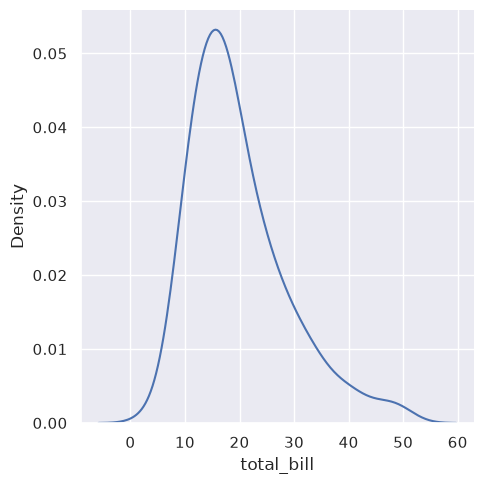

In [23]:
sns.displot(tips, x="total_bill", kind="kde")

`cut=0` stops drawing at the data extremes, but the estimate still smooths into the impossible region, so it's **artificially low** at the edges:

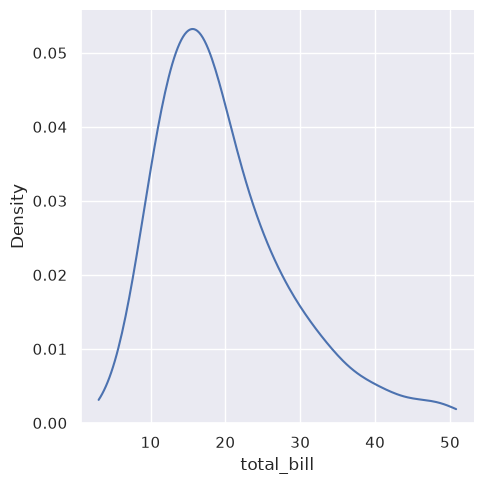

In [24]:
sns.displot(tips, x="total_bill", kind="kde", cut=0)

**2. Discrete or "lumpy" data.** KDE **always** shows a smooth curve, even when the data are not smooth. Diamond weights:

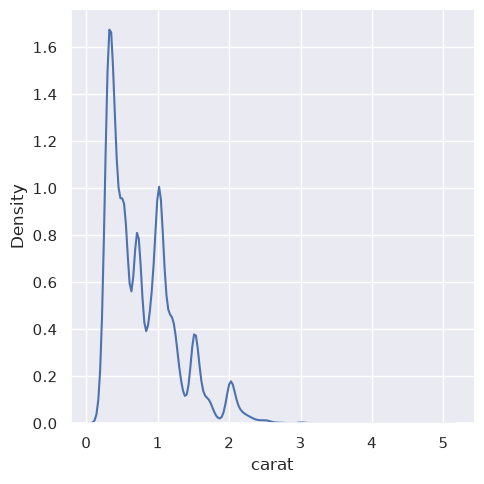

In [25]:
diamonds = sns.load_dataset("diamonds")
sns.displot(diamonds, x="carat", kind="kde")

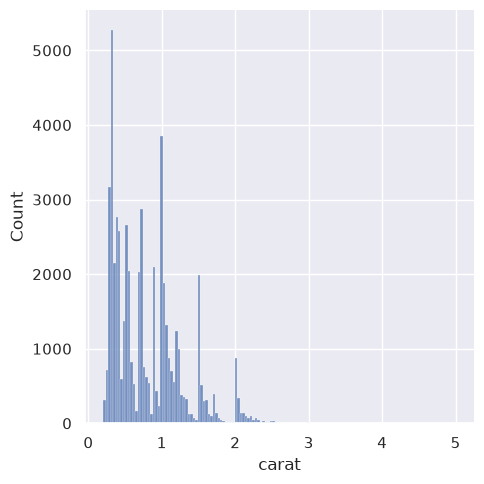

In [26]:
# The histogram shows how jagged the data really are (people buy round sizes: 1.0, 1.5, 2.0 carat)
sns.displot(diamonds, x="carat")

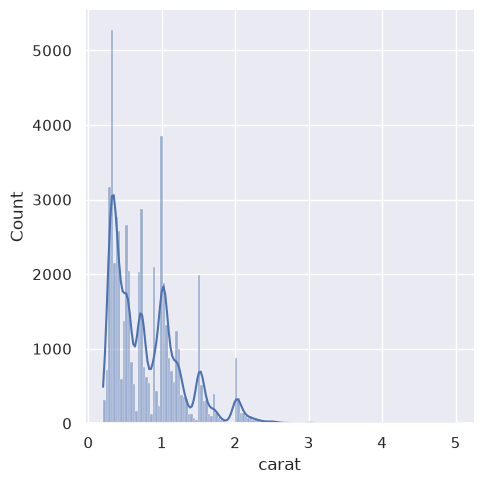

In [27]:
# Compromise: histogram + KDE curve  (kde=True, NOT kind="kde")
sns.displot(diamonds, x="carat", kde=True)

## Empirical cumulative distributions

The **ECDF**: a monotonically increasing curve through each data point; its height = the **proportion of observations ≤ x**.

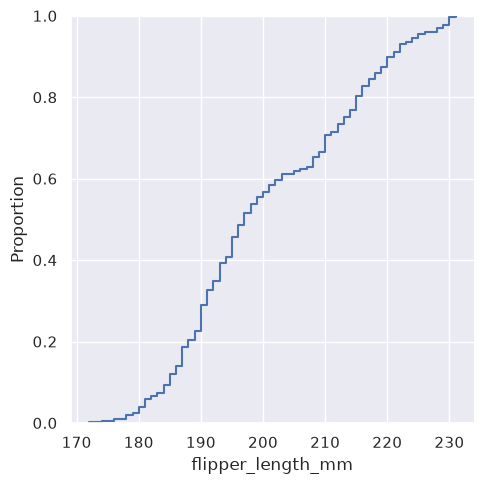

In [28]:
sns.displot(penguins, x="flipper_length_mm", kind="ecdf")

Advantages: it shows **every data point directly** (no bin size or bandwidth to choose), and since the curves only go up, it's great for **comparing** distributions:

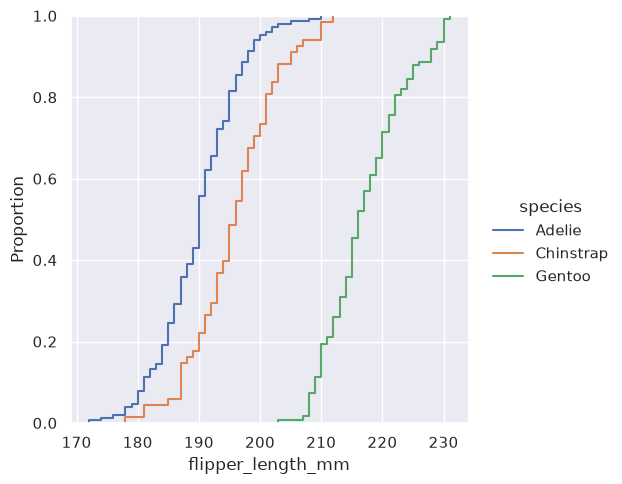

In [29]:
sns.displot(penguins, x="flipper_length_mm", hue="species", kind="ecdf")

Downside: the **shape** is less intuitive. Bimodality is obvious in the histogram; in the ECDF you have to look for changes in slope. With practice, the ECDF answers all the important questions.

## Visualizing bivariate distributions

Assign a second variable to `y` → a **bivariate** distribution. The bivariate histogram bins into rectangles and shows the count as colour (like a heatmap):

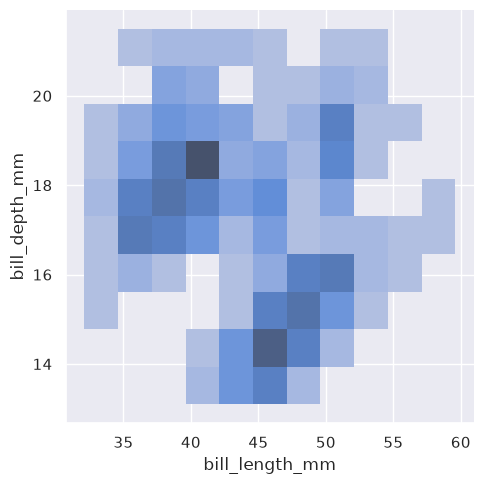

In [30]:
sns.displot(penguins, x="bill_length_mm", y="bill_depth_mm")

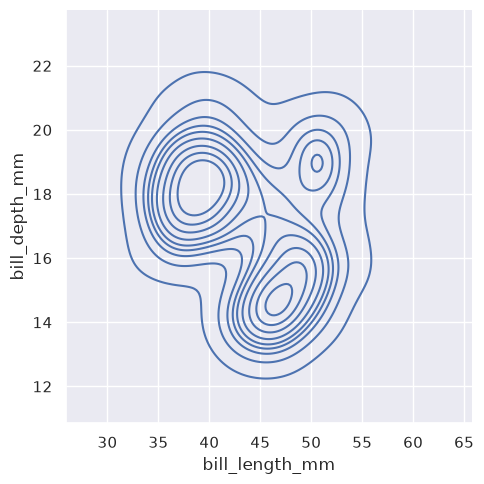

In [31]:
# Bivariate KDE: a 2-D Gaussian smoothing, drawn as density contours
sns.displot(penguins, x="bill_length_mm", y="bill_depth_mm", kind="kde")

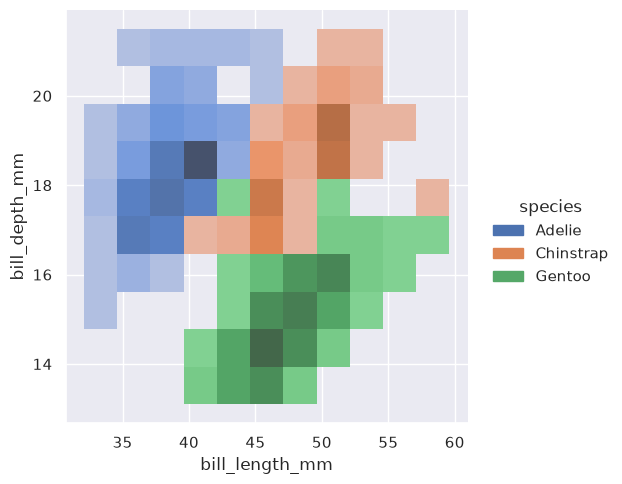

In [32]:
# hue -> one heatmap per level (only works if they barely overlap)
sns.displot(penguins, x="bill_length_mm", y="bill_depth_mm", hue="species")

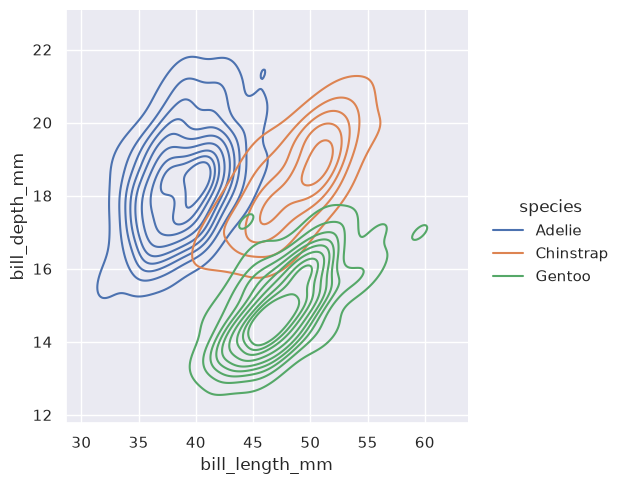

In [33]:
# Contours handle overlap better (but too many contours get busy)
sns.displot(penguins, x="bill_length_mm", y="bill_depth_mm", hue="species", kind="kde")

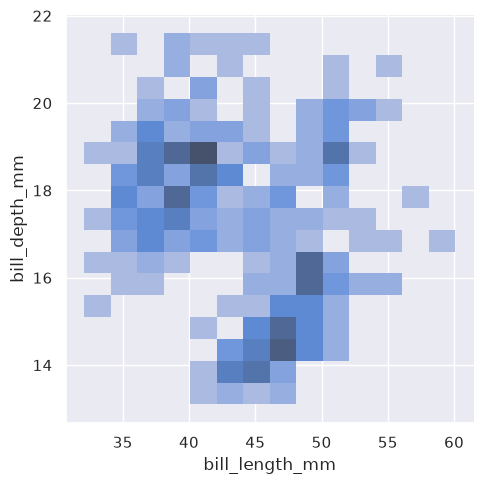

In [34]:
# Tune bins per variable with a pair of values
sns.displot(penguins, x="bill_length_mm", y="bill_depth_mm", binwidth=(2, .5))

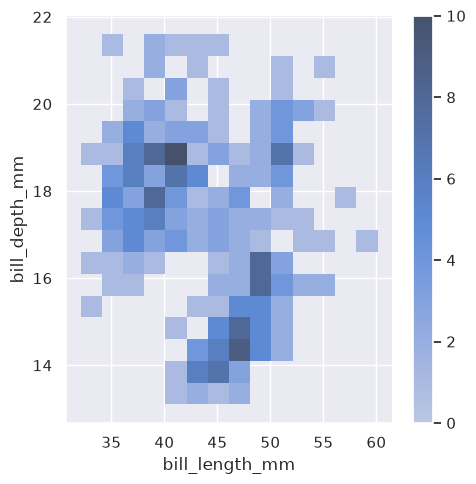

In [35]:
# Add a colorbar so the colour intensity can be read as counts
sns.displot(penguins, x="bill_length_mm", y="bill_depth_mm", binwidth=(2, .5), cbar=True)

Contours are drawn at **iso-proportions**: each line encloses a level such that a proportion *p* of the density lies below it. `thresh` sets the lowest level, `levels` the number:

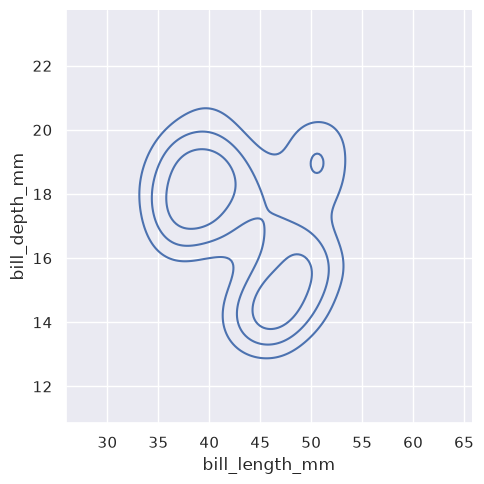

In [36]:
sns.displot(penguins, x="bill_length_mm", y="bill_depth_mm", kind="kde", thresh=.2, levels=4)

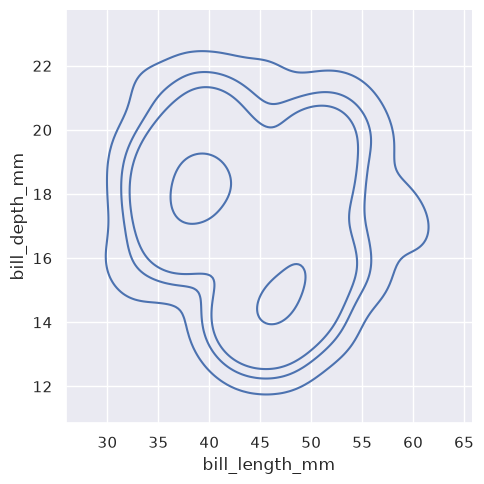

In [37]:
# levels can also be an explicit list
sns.displot(penguins, x="bill_length_mm", y="bill_depth_mm", kind="kde", levels=[.01, .05, .1, .8])

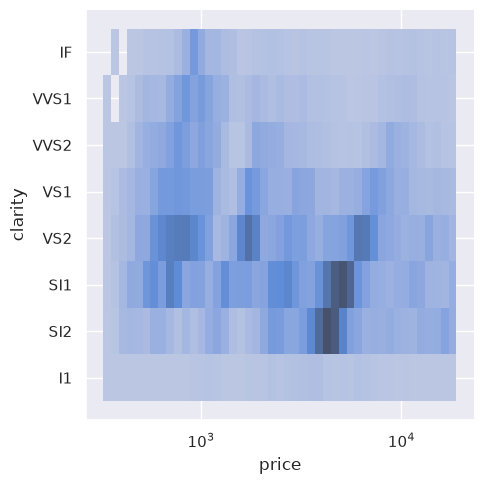

In [38]:
# One discrete + one continuous variable: another way to compare conditional distributions
sns.displot(diamonds, x="price", y="clarity", log_scale=(True, False))   # log x only

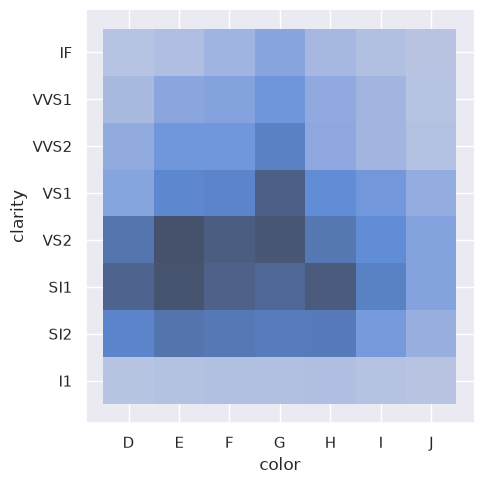

In [39]:
# Two discrete variables: a visual cross-tabulation
sns.displot(diamonds, x="color", y="clarity")

## Distribution visualization in other settings

### Plotting joint and marginal distributions

`jointplot`: a bivariate plot + the **marginal** distribution of each variable. Default: `scatterplot` in the middle, `histplot` on the margins.

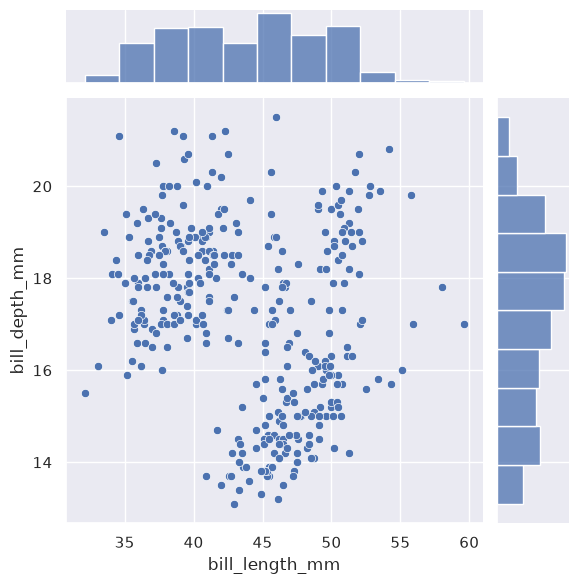

In [40]:
sns.jointplot(data=penguins, x="bill_length_mm", y="bill_depth_mm")

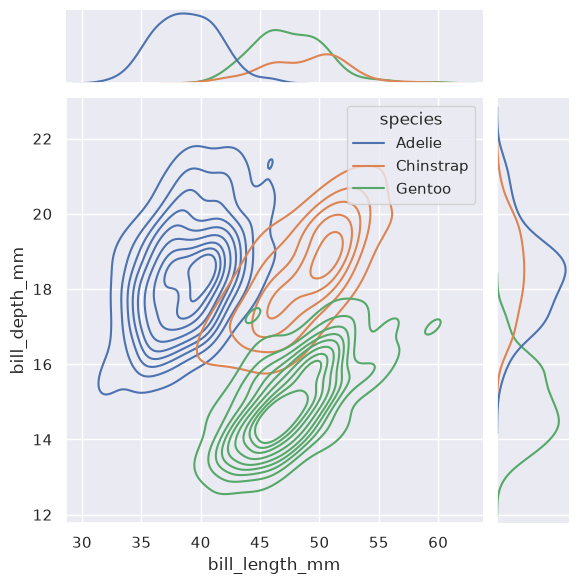

In [41]:
# kind="kde" switches both joint and marginal plots to kdeplot
sns.jointplot(
    data=penguins,
    x="bill_length_mm", y="bill_depth_mm", hue="species",
    kind="kde"
)

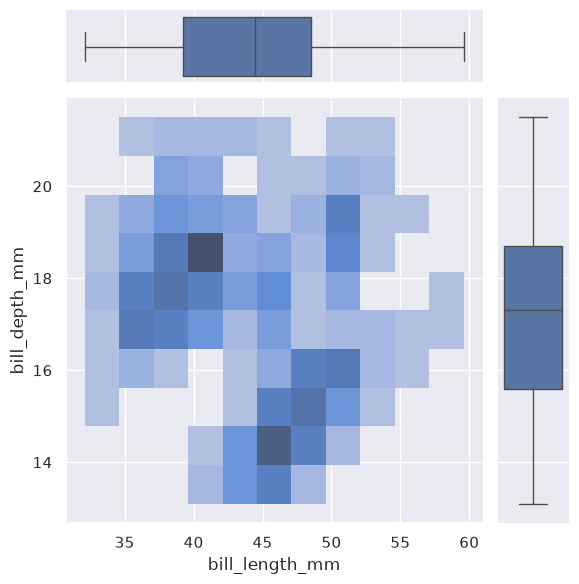

In [42]:
# JointGrid directly: choose any function for the centre and the margins
g = sns.JointGrid(data=penguins, x="bill_length_mm", y="bill_depth_mm")
g.plot_joint(sns.histplot)
g.plot_marginals(sns.boxplot)

A less obtrusive marginal: a **rug** (a small tick per observation on the edge):

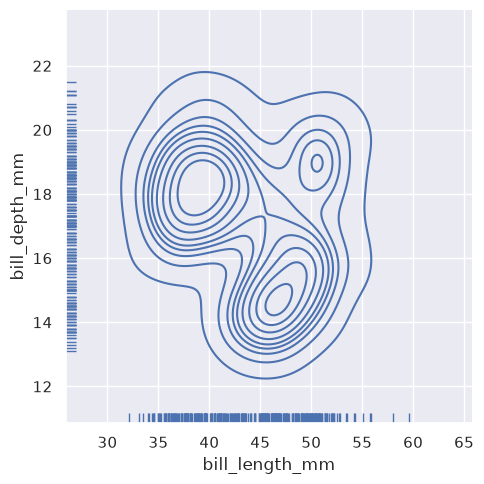

In [43]:
sns.displot(
    penguins, x="bill_length_mm", y="bill_depth_mm",
    kind="kde", rug=True
)

<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

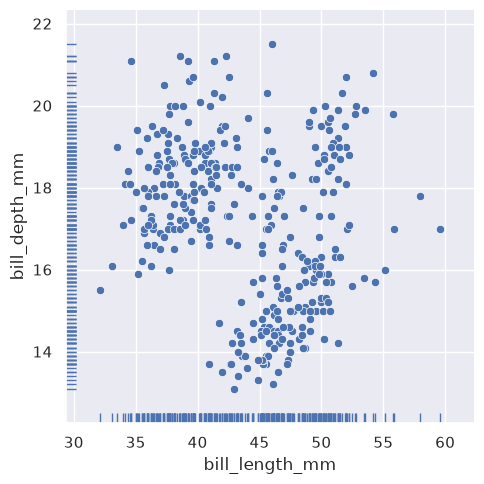

In [44]:
# rugplot (axes-level) adds rugs to any other plot
sns.relplot(data=penguins, x="bill_length_mm", y="bill_depth_mm")
sns.rugplot(data=penguins, x="bill_length_mm", y="bill_depth_mm")   # draws on the current Axes

### Plotting many distributions

`pairplot`: small multiples of every univariate distribution (diagonal) and every pairwise relationship:

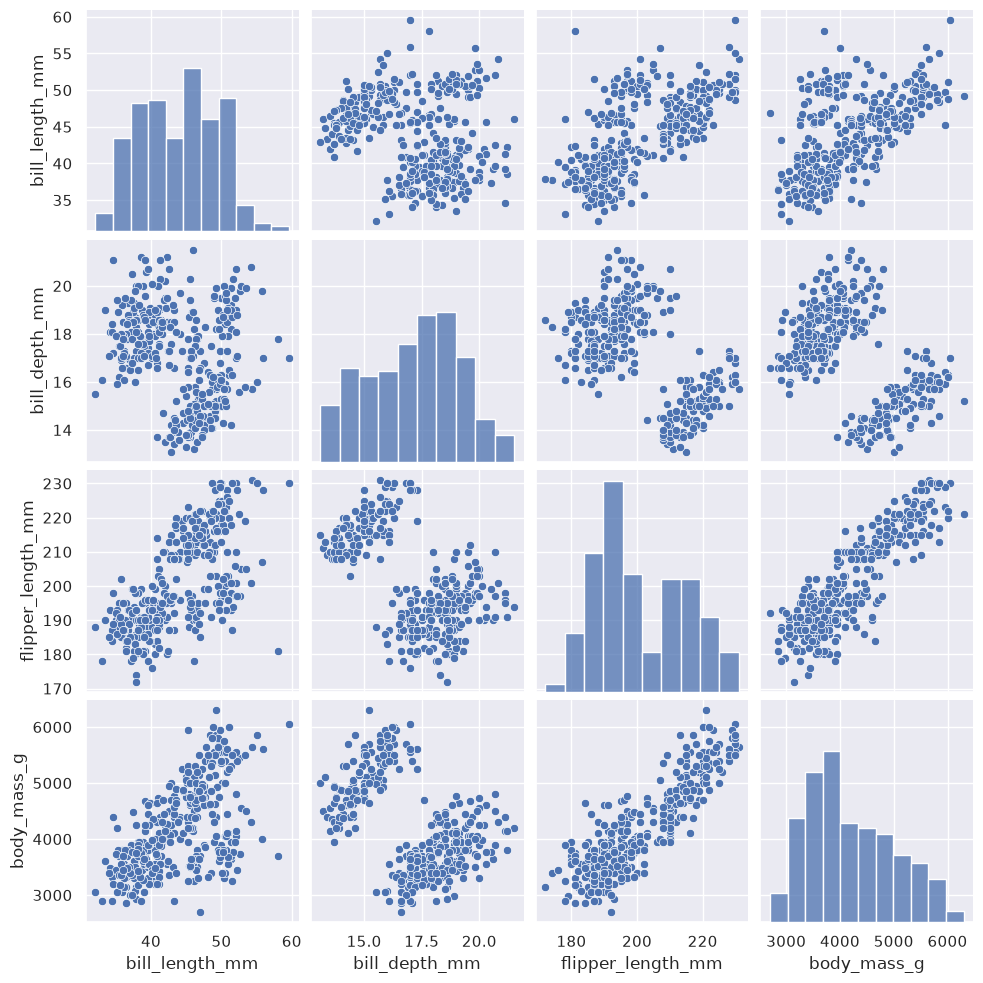

In [45]:
sns.pairplot(penguins)

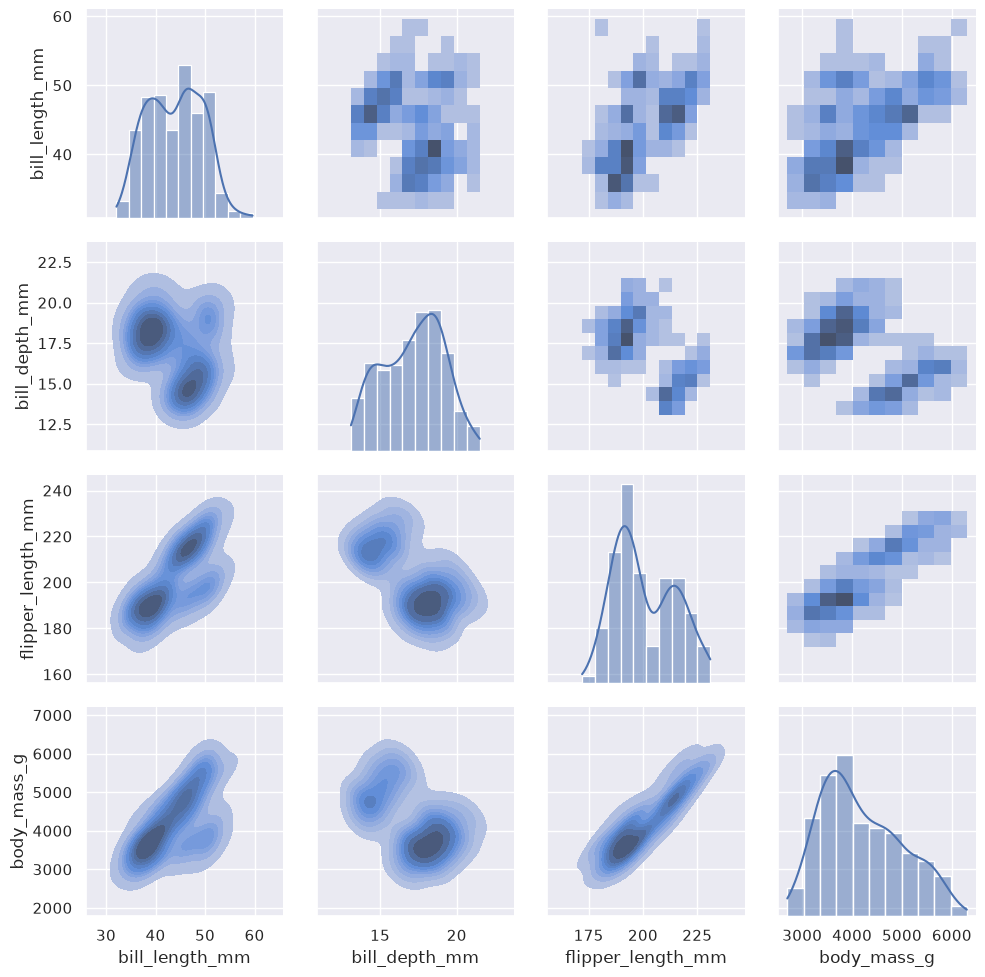

In [46]:
# PairGrid directly: different functions for upper, lower and diagonal
g = sns.PairGrid(penguins)
g.map_upper(sns.histplot)
g.map_lower(sns.kdeplot, fill=True)
g.map_diag(sns.histplot, kde=True)

## Roadmap charts from this page (my addition)

Chart #1 (histogram + density curve) and chart #8 (cumulative distribution) drawn with axes-level functions into my own `fig, axs`:

Text(0.5, 1.0, 'Cumulative distribution (ECDF)')

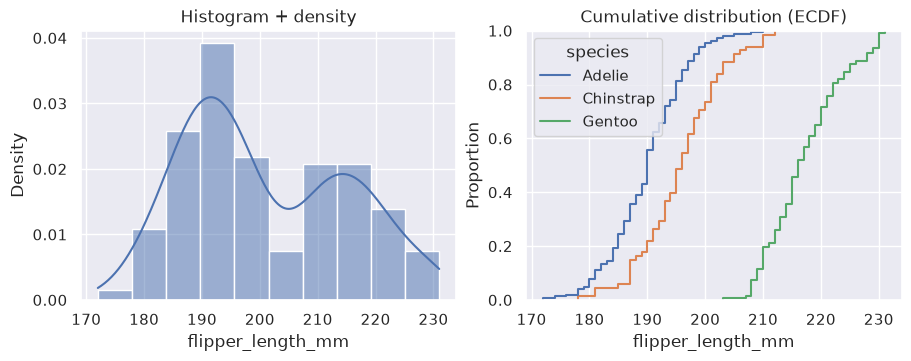

In [47]:
fig, axs = plt.subplots(1, 2, figsize=(9, 3.5), layout="constrained")

# Chart 1: histogram scaled as a density + KDE curve on the same scale
sns.histplot(data=penguins, x="flipper_length_mm", stat="density", kde=True, ax=axs[0])
axs[0].set_title("Histogram + density")

# Chart 8: ECDF per species
sns.ecdfplot(data=penguins, x="flipper_length_mm", hue="species", ax=axs[1])
axs[1].set_title("Cumulative distribution (ECDF)")

## Key takeaways

| Method | Good for | Watch out for |
| :-- | :-- | :-- |
| Histogram (`histplot`) | seeing shape, honest about lumpy data | bin size; use `discrete=True` for integers |
| KDE (`kdeplot`) | comparing smooth shapes across groups | bandwidth (`bw_adjust`); invents values past bounds; hides lumpiness |
| ECDF (`ecdfplot`) | comparing groups, no tuning parameters | shape is less intuitive |

- Unequal group sizes → `stat="density"` / `"probability"` with `common_norm=False`.
- Several groups: `element="step"`, `multiple="stack"|"dodge"`, or facets with `col=`.
- Two variables: bivariate hist / KDE contours; `jointplot` and `pairplot` add marginals.